In [1]:
import numpy as np 
import pandas as pd 
import re
import glob
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub


/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-06-02-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-04-01-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-02-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav


# Merging the Datasests

In [2]:

RAVDESS_PATH = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"
TESS_PATH    = "/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess"
SAVEE_PATH   = "/kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee"
CREMA_PATH   = "/kaggle/input/datasets/ejlok1/cremad"



RAVDESS_MAP = {
    "01": "neutral", "02": "neutral", "03": "happy", "04": "sad",
    "05": "angry", "06": "fear", "07": "disgust", "08": "surprise",
}
SAVEE_MAP = {
    "a": "angry", "d": "disgust", "f": "fear", "h": "happy",
    "n": "neutral", "sa": "sad", "su": "surprise",
}
CREMA_MAP = {
    "ANG": "angry", "DIS": "disgust", "FEA": "fear",
    "HAP": "happy", "NEU": "neutral", "SAD": "sad",
}
TESS_MAP = {
    "angry": "angry", "disgust": "disgust", "fear": "fear", "happy": "happy",
    "neutral": "neutral", "sad": "sad", "ps": "surprise",
}


def _wavs(root):
    return glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)


def parse_ravdess(root):
    for f in _wavs(root):
        code = os.path.basename(f).split("-")[2]
        yield f, RAVDESS_MAP[code], "RAVDESS"


def parse_tess(root):
    for f in _wavs(root):
        token = os.path.splitext(os.path.basename(f))[0].split("_")[-1].lower()
        yield f, TESS_MAP[token], "TESS"


def parse_savee(root):
    for f in _wavs(root):
        token = os.path.splitext(os.path.basename(f))[0].split("_")[-1]
        yield f, SAVEE_MAP[re.sub(r"\d+", "", token)], "SAVEE"


def parse_crema(root):
    for f in _wavs(root):
        code = os.path.basename(f).split("_")[2]
        yield f, CREMA_MAP[code], "CREMA-D"


def build_metadata():
    rows = []
    for parser, root in [
        (parse_ravdess, RAVDESS_PATH),
        (parse_tess, TESS_PATH),
        (parse_savee, SAVEE_PATH),
        (parse_crema, CREMA_PATH),
    ]:
        rows.extend(parser(root))
    df = pd.DataFrame(rows, columns=["path", "emotion", "source"])
    df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)
    return df


if __name__ == "__main__":
    df = build_metadata()
    df.to_csv("ser_metadata.csv", index=False)
    print("total files:", len(df))
    print("\nper source / emotion:")
    print(df.groupby(["source", "emotion"]).size().unstack(fill_value=0))
    print("\nclass totals:")
    print(df["emotion"].value_counts())

total files: 16402

per source / emotion:
emotion  angry  disgust  fear  happy  neutral   sad  surprise
source                                                       
CREMA-D   1271     1271  1271   1271     1087  1271         0
RAVDESS    384      384   384    384      576   384       384
SAVEE       60       60    60     60      120    60        60
TESS       800      800   800    800      800   800       800

class totals:
emotion
neutral     2583
disgust     2515
fear        2515
happy       2515
sad         2515
angry       2515
surprise    1244
Name: count, dtype: int64


# Scan durations and drop unreadable files

In [3]:
import numpy as np
import soundfile as sf
from tqdm.auto import tqdm
tqdm.pandas()

def file_duration(path):
    try:
        return sf.info(path).duration
    except Exception:
        return np.nan

df["duration"] = df["path"].progress_apply(file_duration)

corrupted = df[df["duration"].isna()]
print("unreadable files:", len(corrupted))
df = df.dropna(subset=["duration"]).reset_index(drop=True)
print("clean files:", len(df))

  0%|          | 0/16402 [00:00<?, ?it/s]

unreadable files: 0
clean files: 16402


# durations and class balance:

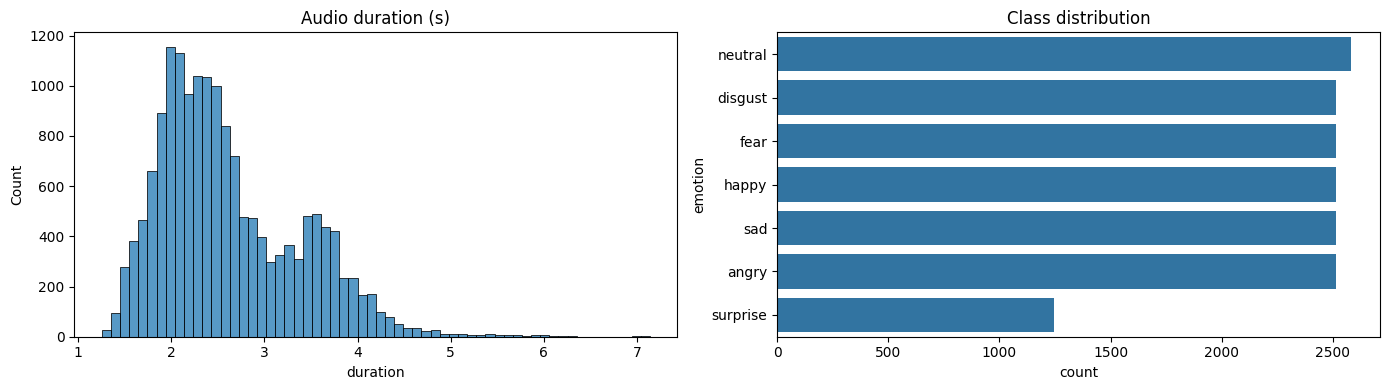

count    16402.000000
mean         2.617590
std          0.751894
min          1.254076
25%          2.064963
50%          2.435750
75%          3.103125
max          7.138730
Name: duration, dtype: float64

class counts:
 emotion
neutral     2583
disgust     2515
fear        2515
happy       2515
sad         2515
angry       2515
surprise    1244
Name: count, dtype: int64

by source:
 emotion  angry  disgust  fear  happy  neutral   sad  surprise
source                                                       
CREMA-D   1271     1271  1271   1271     1087  1271         0
RAVDESS    384      384   384    384      576   384       384
SAVEE       60       60    60     60      120    60        60
TESS       800      800   800    800      800   800       800


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["duration"], bins=60, ax=ax[0])
ax[0].set_title("Audio duration (s)")
sns.countplot(data=df, y="emotion",
              order=df["emotion"].value_counts().index, ax=ax[1])
ax[1].set_title("Class distribution")
plt.tight_layout(); plt.show()

print(df["duration"].describe())
print("\nclass counts:\n", df["emotion"].value_counts())
print("\nby source:\n", df.groupby(["source", "emotion"]).size().unstack(fill_value=0))

In [5]:
%%writefile preprocess.py
import numpy as np
import librosa

SR = 16000
TOP_DB = 25

def preprocess(path, sr=SR, top_db=TOP_DB):
    y, _ = librosa.load(path, sr=sr, mono=True)
    yt, _ = librosa.effects.trim(y, top_db=top_db)
    if yt.size > 0:
        y = yt
    peak = np.max(np.abs(y))
    if peak > 0:
        y = y / peak
    return y.astype(np.float32)

Writing preprocess.py


# feature extraction

In [6]:
%%writefile feature_extract.py
import numpy as np
import librosa
from preprocess import preprocess, SR

N_MFCC = 40
N_MELS = 128

def _stats(feat):
    return np.concatenate([feat.mean(axis=1), feat.std(axis=1)])

def extract_features(path, sr=SR):
    y = preprocess(path, sr=sr)
    stft = np.abs(librosa.stft(y))
    parts = [
        _stats(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)),
        _stats(librosa.feature.chroma_stft(S=stft, sr=sr)),
        _stats(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)),
        _stats(librosa.feature.spectral_centroid(S=stft, sr=sr)),
        _stats(librosa.feature.spectral_rolloff(S=stft, sr=sr)),
        _stats(librosa.feature.zero_crossing_rate(y)),
        _stats(librosa.feature.rms(S=stft)),
    ]
    return np.concatenate(parts).astype(np.float32)

Writing feature_extract.py


In [7]:
import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from feature_extract import extract_features

def safe_extract(path):
    try:
        return extract_features(path)
    except Exception:
        return None

results = Parallel(n_jobs=-1)(
    delayed(safe_extract)(p) for p in tqdm(df["path"])
)

mask = [r is not None for r in results]
X = np.vstack([r for r in results if r is not None])
y = df.loc[mask, "emotion"].to_numpy()

np.save("X.npy", X)
np.save("y.npy", y)
df.loc[mask].reset_index(drop=True).to_csv("ser_metadata_clean.csv", index=False)

print("X:", X.shape, "| y:", y.shape, "| dropped:", (~np.array(mask)).sum())

  0%|          | 0/16402 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


X: (16402, 368) | y: (16402,) | dropped: 0


# Preprocessing 

In [8]:
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

X = np.load("X.npy")
y_raw = np.load("y.npy", allow_pickle=True)

le = LabelEncoder()
y = le.fit_transform(y_raw)
print("classes:", list(le.classes_))

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

joblib.dump(le, "label_encoder.joblib")
joblib.dump(scaler, "scaler.joblib")

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
train: (11481, 368) val: (2460, 368) test: (2461, 368)


In [9]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
print(class_weight)

{np.int64(0): np.float64(0.9318993506493507), np.int64(1): np.float64(0.9313701630567048), np.int64(2): np.float64(0.9318993506493507), np.int64(3): np.float64(0.9318993506493507), np.int64(4): np.float64(0.9071586599241467), np.int64(5): np.float64(0.9313701630567048), np.int64(6): np.float64(1.8830572412661966)}


In [10]:

from imblearn.over_sampling import SMOTE
X_train_bal, y_train_bal = SMOTE(random_state=42).fit_resample(X_train, y_train)
print("balanced train:", X_train_bal.shape)

balanced train: (12656, 368)


# Models Training

In [11]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

models = {
    "LogReg":       LogisticRegression(max_iter=2000, class_weight=class_weight),
    "SVM":          SVC(kernel="rbf", C=10, gamma="scale", class_weight=class_weight),
    "RandomForest": RandomForestClassifier(n_estimators=400, class_weight=class_weight,
                                           n_jobs=-1, random_state=42),
    "KNN":          KNeighborsClassifier(n_neighbors=7, weights="distance", n_jobs=-1),
}

rows, fitted = [], {}
for name, model in models.items():
    Xtr, ytr = (X_train_bal, y_train_bal) if name == "KNN" else (X_train, y_train)
    model.fit(Xtr, ytr)
    pred = model.predict(X_val)
    rows.append({"model": name,
                 "val_acc": accuracy_score(y_val, pred),
                 "val_f1_macro": f1_score(y_val, pred, average="macro")})
    fitted[name] = model

results = pd.DataFrame(rows).sort_values("val_f1_macro", ascending=False)
print(results.to_string(index=False))

       model  val_acc  val_f1_macro
         SVM 0.749187      0.763544
RandomForest 0.732927      0.748080
         KNN 0.673984      0.685083
      LogReg 0.666667      0.680092


In [12]:
from sklearn.model_selection import GridSearchCV


grid = {"C": [1, 10, 50], "gamma": ["scale", 0.01, 0.001]}
gs = GridSearchCV(SVC(kernel="rbf", class_weight=class_weight, probability=True),
                  grid, scoring="f1_macro", cv=3, n_jobs=-1, verbose=1)


gs.fit(X_train, y_train)
print("best params:", gs.best_params_)
print("cv f1_macro:", round(gs.best_score_, 4))

best_model = gs.best_estimator_
print("val f1_macro:", round(f1_score(y_val, best_model.predict(X_val), average="macro"), 4))

Fitting 3 folds for each of 9 candidates, totalling 27 fits
best params: {'C': 10, 'gamma': 'scale'}
cv f1_macro: 0.7309
val f1_macro: 0.7635


In [13]:
import numpy as np, joblib

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
best_model.fit(X_trainval, y_trainval)

joblib.dump(best_model, "ser_model.joblib")
print("saved ser_model.joblib")

saved ser_model.joblib


In [14]:
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

y_pred = best_model.predict(X_test)

print("accuracy    :", round(accuracy_score(y_test, y_pred), 4))
print("macro F1    :", round(f1_score(y_test, y_pred, average="macro"), 4))
print("weighted F1 :", round(f1_score(y_test, y_pred, average="weighted"), 4))
print()
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=3))

accuracy    : 0.7501
macro F1    : 0.7642
weighted F1 : 0.7491

              precision    recall  f1-score   support

       angry      0.742     0.791     0.766       378
     disgust      0.711     0.645     0.676       377
        fear      0.755     0.660     0.704       377
       happy      0.708     0.712     0.710       378
     neutral      0.738     0.807     0.771       388
         sad      0.739     0.790     0.764       377
    surprise      0.978     0.941     0.959       186

    accuracy                          0.750      2461
   macro avg      0.767     0.764     0.764      2461
weighted avg      0.751     0.750     0.749      2461

